# Immune Repertoire Analysis of CD4 T-Cell TCR Alpha Clonotypes

### Introduction

T-cell receptor (TCR) repertoire sequencing enables high-resolution profiling of adaptive immune diversity by characterizing clonotype composition, V(D)J gene usage, and CDR3 sequence variability. Understanding repertoire structure provides insight into immune status, clonal expansion, and antigen-driven selection.

In this project, we analyze a processed TCR α-chain clonotype dataset derived from CD4 T-cell populations. The dataset contains clonotype-level information including clone counts, gene assignments, and CDR3 sequences. Using Python-based data analysis tools, we perform:

Clonotype diversity estimation (Shannon and Simpson indices)

V gene and J gene usage profiling

CDR3 length distribution analysis

Visualization of repertoire characteristics

All analyses are conducted at the clonotype level using processed immune repertoire tables.

### Library Imports

This cell imports the core Python libraries used throughout the analysis.
Pandas and NumPy are used for data manipulation and numerical operations.
SciPy provides statistical functions (e.g., Shannon entropy for diversity analysis).
Matplotlib and Seaborn are used for data visualization.
Pathlib helps manage file paths in a clean and platform-independent way.
These libraries form the foundation for immune repertoire data processing, statistical analysis, and visualization.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Dataset Description
Overview

This project uses a subset of processed immune repertoire sequencing dataset in clonotype table format. The data represent T-cell receptor (TCR) repertoires derived from sorted immune cell populations, including:

CD4 T cells  
CD8 T cells  
Memory T cells  
Peripheral Blood Mononuclear Cells (PBMC)  
See the dataset used in this analysis here- https://drive.google.com/file/d/1G-RegVzpfEFg7ydjL0EZ154iETk1t86X/view?usp=sharing 

The dataset is provided as compressed tab-delimited files (.txt.gz) and contains post-processed clonotype-level information rather than raw sequencing reads (FASTQ).

📁 Data Structure

Each file contains clonotype-level information with the following columns:

cloneId- Unique identifier for each clonotype
cloneCount- Number of sequencing reads supporting the clonotype
cloneFraction- Relative frequency of the clonotype within the sample
clonalSequence - Nucleotide sequence of the CDR3 region
bestVGene -	Assigned V gene
bestDGene -	Assigned D gene (if applicable)
bestJGene -	Assigned J gene
bestVFamily - V gene family classification
bestJFamily	- J gene family classification
aaSeqCDR3 -	Amino acid sequence of the CDR3 region
nSeqCDR3 -	Nucleotide CDR3 sequence
refPoints -	Alignment reference point annotations

🔬 Data Processing Background  
The column structure and naming convention are consistent with clonotype export generated by MiXCR, a widely used immune repertoire sequencing analysis tool.

The dataset therefore represents processed clonotype tables generated after:  
V(D)J alignment  
CDR3 extraction  
Clonotype assembly  
Abundance quantification  
All analyses in this project are performed at the clonotype level.  

⚠️ Data Source Note  
The original sequencing accession number or repository identifier was not available with the dataset.  
For the purposes of this project, the files are treated as publicly available processed immune repertoire data and are used strictly for methodological development and analytical demonstration.

🧬 Usage in This Project
The dataset is used to:  
Compute clonotype diversity metrics (e.g., Shannon entropy)  
Analyze V/J gene usage  
Compare repertoire characteristics across immune cell subsets  
Visualize clonotype frequency distributions  

### Load Clonotype Data

This cell loads the processed clonotype table into a Pandas DataFrame using tab-separated formatting.

The dataset (M_15_CD4_alpha.txt) contains TCR clonotype information for a CD4 T-cell subset.
df.head() is used to preview the first few rows and verify that the data were loaded correctly before proceeding with analysis.

In [3]:
df = pd.read_csv('M_15_CD4_alpha.txt', sep="\t")


In [4]:
df.head()

,cloneId,cloneCount,cloneFraction,clonalSequence,bestVGene,bestDGene,bestJGene,bestVFamily,bestJFamily,aaSeqCDR3,nSeqCDR3,refPoints
0,0,4915,0.016097,TGTGCTGTGAGTACCCCATCAGGAGGAAGCTACATACCTACATTT,TRAV8-6,NaN,TRAJ6,TRAV8,TRAJ6,CAVSTPSGGSYIPTF,TGTGCTGTGAGTACCCCATCAGGAGGAAGCTACATACCTACATTT,:::::::::0:-2:12:::::16:-2:45:::
1,1,926,0.003033,TGTGCAGAGAGCTACTATACTGGAGGCTTCAAAACTATCTTT,TRAV5,NaN,TRAJ9,TRAV5,TRAJ9,CAESYYTGGFKTIF,TGTGCAGAGAGCTACTATACTGGAGGCTTCAAAACTATCTTT,:::::::::0:-2:11:::::16:-4:42:::
2,2,784,0.002568,TGTGCCGTGAACAGGGCTGCAGGCAACAAGCTAACTTTT,TRAV12-2,NaN,TRAJ17,TRAV12,TRAJ17,CAVNRAAGNKLTF,TGTGCCGTGAACAGGGCTGCAGGCAACAAGCTAACTTTT,:::::::::0:0:13:::::15:-8:39:::
3,3,766,0.002509,TGTGCCGTAAGATGGGATAATGCAGGCAACATGCTCACCTTT,TRAV13-2,NaN,TRAJ39,TRAV13,TRAJ39,CAVRWDNAGNMLTF,TGTGCCGTAAGATGGGATAATGCAGGCAACATGCTCACCTTT,:::::::::0:-8:5:::::16:-6:42:::
4,4,574,0.001880,TGTGTGGTGACCAGGAACACAGGCTTTCAGAAACTTGTATTT,TRAV10,NaN,TRAJ8,TRAV10,TRAJ8,CVVTRNTGFQKLVF,TGTGTGGTGACCAGGAACACAGGCTTTCAGAAACTTGTATTT,:::::::::0:-3:10:::::11:2:42:::


### Clonotype Diversity Analysis

This cell computes repertoire diversity metrics based on clonotype frequencies.

Relative frequencies are calculated from cloneCount.

Shannon entropy measures overall diversity and richness.

Simpson diversity index reflects dominance and evenness within the repertoire.

The results are stored in a summary DataFrame (diversity_df) for downstream visualization and comparison.

In [10]:
# Clonotype diversity
# =========================
freq = df["cloneCount"] / df["cloneCount"].sum()

shannon_div = entropy(freq)
simpson_div = 1 - np.sum(freq ** 2)

diversity_df = pd.DataFrame({
    "Metric": ["Shannon", "Simpson"],
    "Value": [shannon_div, simpson_div]
})

In [ ]:
#see the result of diversity
diversity_df

,Metric,Value
0,Shannon,11.353071
1,Simpson,0.999676


📈 Diversity Results Interpretation

The calculated diversity metrics indicate a highly diverse CD4 T-cell repertoire.

Shannon index (11.35) suggests substantial clonotype richness and even distribution.

Simpson index (0.9997) is very close to 1, indicating minimal dominance by individual clonotypes and a highly even repertoire.

Overall, these results are consistent with a polyclonal and diverse TCR repertoire, which is typical for healthy peripheral T-cell populations.

In [ ]:
#save the result of diversity in a csv file
diversity_df.to_csv("diversity_metrics.csv", index=False)

### V and J Gene Usage Analysis

This cell calculates the relative usage frequencies of V and J genes within the repertoire.

value_counts(normalize=True) computes proportional gene usage.

V gene and J gene distributions are derived from bestVGene and bestJGene columns.

The results are exported as CSV files for downstream analysis or visualization.

These gene usage profiles help characterize repertoire bias and potential selection patterns within the CD4 T-cell population.

In [ ]:
v_usage = df["bestVGene"].value_counts(normalize=True)
j_usage = df["bestJGene"].value_counts(normalize=True)
v_usage.to_csv("v_gene_usage.csv", header=["frequency"])
j_usage.to_csv("j_gene_usage.csv", header=["frequency"])


### CDR3 Length Distribution

This cell calculates the amino acid length of each CDR3 sequence.

The CDR3 length is derived from the aaSeqCDR3 column.

A new column (cdr3_length) is added to the DataFrame.

The length distribution is exported for downstream statistical analysis or visualization.

CDR3 length is an important structural feature that reflects junctional diversity and repertoire variability.

In [26]:
# =========================
# CDR3 length distribution
# =========================
df["cdr3_length"] = df["aaSeqCDR3"].str.len()
df[["cdr3_length"]].to_csv("cdr3_length.csv", index=False)

### V Gene Usage Visualization

This cell generates a bar plot of the top 15 most frequently used V genes.

The plot displays relative gene usage frequencies.

Visualization helps identify dominant or preferentially used V genes.

The figure is saved as v_gene_usage.png for reporting and documentation.

This provides a quick overview of gene usage bias within the CD4 T-cell repertoire

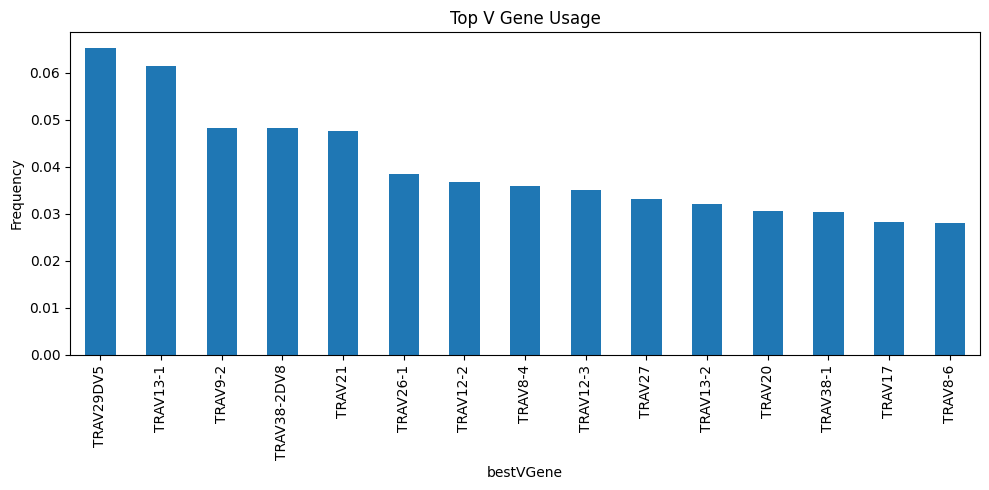

In [29]:
# =========================
# Plots
# =========================

# V gene usage plot
plt.figure(figsize=(10, 5))
v_usage.head(15).plot(kind="bar")
plt.title("Top V Gene Usage")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig( "v_gene_usage.png")
plt.show()

### Interpretation: Top V Gene Usage

The bar chart shows the top 15 most frequently used V genes in the CD4 T-cell repertoire.

TRAV29DV5 and TRAV13-1 are the most dominant V genes, each contributing over ~6% of total clonotypes.

Several other genes (e.g., TRAV9-2, TRAV38-2DV8, TRAV21) show moderately high usage (~4–5%).

The distribution gradually decreases rather than showing extreme dominance by a single gene.

🔬 Biological Interpretation

The pattern suggests:

A biased but polyclonal repertoire

No single V gene overwhelmingly dominates

Typical gene usage variability seen in healthy T-cell populations

Overall, the repertoire shows preferential V gene usage while maintaining broad diversity.

### J Gene Usage Visualization

This cell generates a bar plot showing the relative usage frequencies of J genes.

The plot illustrates the distribution of J gene segment usage across the repertoire.

It helps identify dominant or preferentially selected J genes.

The figure is saved as j_gene_usage.png for documentation and reporting.

This visualization complements the V gene analysis and provides insight into overall V–J recombination patterns.

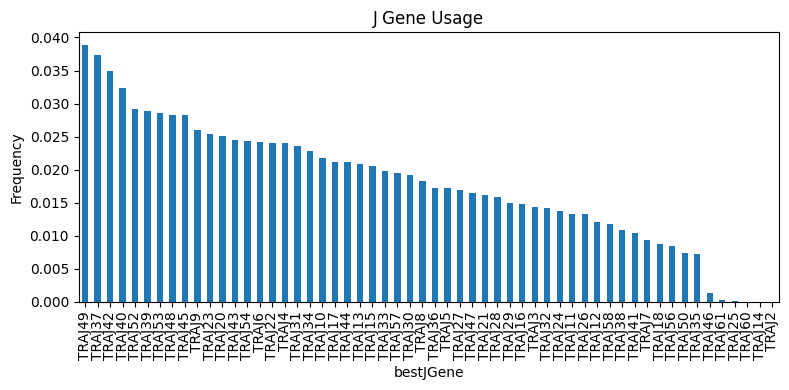

In [31]:
# J gene usage plot
plt.figure(figsize=(8, 4))
j_usage.plot(kind="bar")
plt.title("J Gene Usage")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("j_gene_usage.png")
plt.show()

### Interpretation: J Gene Usage

The bar chart displays the relative frequency of J gene segment usage across the CD4 T-cell repertoire.

TRAJ49, TRAJ37, and TRAJ24 show the highest usage (~3.5–4%).

The distribution gradually declines across many J genes.

No single J gene overwhelmingly dominates the repertoire.

🔬 Biological Interpretation

This pattern indicates:

A broad and diverse J gene utilization

Mild preferential usage of certain TRAJ segments

A generally polyclonal repertoire without strong clonal restriction

The smooth distribution across many J genes supports the high diversity observed in the Shannon and Simpson diversity metrics.

### CDR3 Length Distribution Visualization

This cell visualizes the distribution of CDR3 amino acid lengths using a histogram.

The histogram displays the frequency of clonotypes across different CDR3 lengths.

This helps assess structural variability and repertoire diversity.

The figure is saved as cdr3_length_distribution.png for reporting and further analysis.

CDR3 length distribution is an important characteristic of TCR repertoire architecture and reflects junctional diversity.

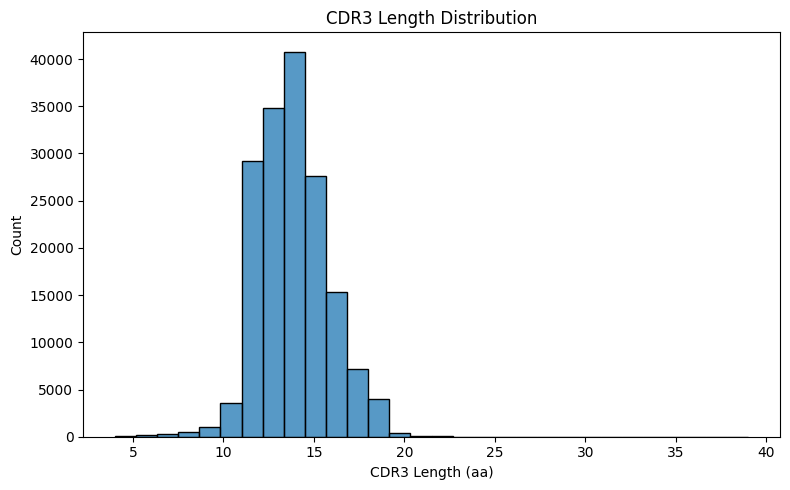

In [39]:
# CDR3 length distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["cdr3_length"], bins=30)
plt.title("CDR3 Length Distribution")
plt.xlabel("CDR3 Length (aa)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("cdr3_length_distribution.png")
plt.show()


### Interpretation: CDR3 Length Distribution

The histogram shows the distribution of CDR3 amino acid lengths in the CD4 T-cell repertoire.

The distribution is approximately bell-shaped (near normal).

Most CDR3 sequences fall between 11–16 amino acids.

The peak appears around 13–14 amino acids, which is typical for TCR α-chain repertoires.

Very short and very long CDR3 sequences are rare.

🔬 Biological Interpretation

This pattern indicates:

A structurally typical TCR repertoire

Balanced junctional diversity

No abnormal skewing toward unusually long or short CDR3 regions

The compact, symmetric distribution supports the conclusion of a healthy, polyclonal repertoire consistent with the high diversity metrics observed earlier.

### Conclusion

The analyzed CD4 T-cell repertoire demonstrates characteristics consistent with a highly diverse and polyclonal immune population:

High Shannon entropy and near-maximal Simpson diversity indicate broad clonotype richness and minimal dominance.

V and J gene usage patterns show preferential gene utilization without extreme skewing.

The CDR3 length distribution follows a near-normal pattern centered around typical TCR α-chain lengths (13–14 amino acids).

Together, these results suggest a structurally balanced and diverse TCR repertoire, consistent with a physiologically heterogeneous CD4 T-cell population.

This project demonstrates how immune repertoire datasets can be explored computationally to extract meaningful biological insights using reproducible Python workflows.